#Lab 1
Day vs. Night Image Classification with Neural Networks

**Build & Export Model**

In the first part of this practical exercise, we will train a model and store the necessary "artifacts" (files resulting from training) required for deployment. This will be accomplished by performing Image Classification (Day vs Night) using a Neural Network.

**Step 1: Import Libraries and Mount Google Drive**

The initial step is to import the libraries required for image processing, machine learning, and deep learning, and to connect Google Colab with Google Drive.

In [ ]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import cv2

from skimage.feature import hog
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras import layers, models

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Step 2: Load Dataset**

Read images from the directory training and testing, then store them in a list together with their labels.

In [ ]:
# Load images and labels from a directory structure
def load_dataset(img_dir):
    p = Path(img_dir)
    img_list = []
    for folder in p.glob('*'):
        label = folder.name
        for file in folder.glob('*.jpg'):
            img = cv2.imread(str(file))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img_list.append((img, label))
    return img_list

train_dir = "/content/drive/MyDrive/Machine Learning 2025/images/training/"
test_dir  = "/content/drive/MyDrive/Machine Learning 2025/images/test"

train_img = load_dataset(train_dir)
test_img  = load_dataset(test_dir)

print(f"Number of training samples: {len(train_img)}")
print(f"Number of testing samples: {len(test_img)}")

Number of training samples: 240
Number of testing samples: 160


**Step 3: Preprocessing (Resize & Label Encoding)**

Resize images to 256x256 pixels and convert textual labels ('day'/'night') into binary numeric values (1/0).

In [ ]:
# Preprocess images: resize and encode labels
def resize_image(img, size=(256,256)):
    return cv2.resize(img, size)

def label_encoder(label):
    return 1 if label == 'day' else 0

def preprocess(img_list):
    X = []
    y = []
    for img, label in img_list:
        img_std = resize_image(img)
        X.append(img_std)
        y.append(label_encoder(label))
    return X, y

X_train_img, y_train = preprocess(train_img)
X_test_img,  y_test  = preprocess(test_img)

**Step 4: HOG Feature Extraction (Histogram of Oriented Gradients)**

Extract shape and texture features from images using the HOG method.

In [ ]:
# Extract HOG features
def extract_hog(X_imgs):
    feats = []
    for img in X_imgs:
        gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
        hog_feat = hog(gray,
                       orientations=9,
                       pixels_per_cell=(8,8),
                       cells_per_block=(2,2),
                       block_norm='L2-Hys',
                       visualize=False,
                       feature_vector=True)
        feats.append(hog_feat)
    return np.array(feats)

X_train_feat = extract_hog(X_train_img)
X_test_feat  = extract_hog(X_test_img)

**Step 5: Feature Normalization**

Standardize the features to have mean 0 and variance 1 using StandardScaler.

In [ ]:
# Normalize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_feat)
X_test_scaled  = scaler.transform(X_test_feat)

**Step 6: Split Training & Validation Data**

Partition the training data into and train.

In [ ]:
# Split training data for validation
X_train, X_val, y_train, y_val = train_test_split(
    X_train_scaled, y_train,
    test_size=0.2,
    random_state=42
)

**Step 7: Convert Labels to Numpy Array Transform the label lists into numpy array**

In [ ]:
# format so as to be compatible with TensorFlow/Keras.
# Convert labels to numpy arrays (required for Keras)
y_train = np.array(y_train)
y_val = np.array(y_val)
y_test = np.array(y_test)

**Step 8: Construct Neural Network Model Architecture Create a Sequential**

In [ ]:
# model with three layers (Input, Hidden Layers with ReLU, and an Output Layer with Sigmoid).
# Build a simple feedforward neural network
# Define model architecture
# input_dim is the number of features in the dataset
# Hidden layer -> 128 neurons, ReLU activation
# Hidden layer -> 64 neurons, ReLU activation
# Output layer -> 1 neuron, Sigmoid activation (for binary classification)

input_dim = X_train.shape[1]
model = models.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │     4,428,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,436,737 (16.92 MB)

 Trainable params: 4,436,737 (16.92 MB)

 Non-trainable params: 0 (0.00 B)

**Step 9: Model Training training Train the model using the**

In [ ]:
# data for 20 epochs.
# Train the model
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_val, y_val)
)

Epoch 1/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 134ms/step - accuracy: 0.7254 - loss: 1.2307 - val_accuracy: 0.9792 - val_loss: 0.5982
Epoch 2/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step - accuracy: 0.9928 - loss: 0.0141 - val_accuracy: 0.9375 - val_loss: 0.9727
Epoch 3/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 1.0000 - loss: 3.7229e-05 - val_accuracy: 0.9375 - val_loss: 1.2394
Epoch 4/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 146ms/step - accuracy: 1.0000 - loss: 1.9787e-04 - val_accuracy: 0.9375 - val_loss: 1.3613
Epoch 5/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 133ms/step - accuracy: 1.0000 - loss: 2.3457e-04 - val_accuracy: 0.9375 - val_loss: 1.3866
Epoch 6/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 120ms/step - accuracy: 1.0000 - loss: 4.2633e-06 - val_accuracy: 0.9375 - val_loss: 1.3601
Epoch 7/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 133ms/step - accuracy: 1.0000 - loss: 1.3520e-06 - val_accuracy: 0.9375 - val_loss: 1.3432
Epoch 8/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 141ms/step - accuracy: 1.0000 - loss: 1.1439e-06 - val_accura

**Step 10: Model Evaluation testing**

In [ ]:
# Assess the model's performance on the
# Evaluate the model on test data
test_loss, test_acc = model.evaluate(X_test_scaled, y_test)
print("Test Accuracy:", test_acc)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8457 - loss: 3.8996
Test Accuracy: 0.893750011920929


In [ ]:
print(history.history.keys())
# Should show: dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])


dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


**Step 11: Prediction and Classification Report as well as Visualization Generate predictions on the test data and display the classification report and the.**

In [ ]:
# confusion matrix
# Generate classification report and confusion matrix
y_pred_prob = model.predict(X_test_scaled)

y_pred = (y_pred_prob > 0.5).astype(int)
print(classification_report(y_test, y_pred))

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
              precision    recall  f1-score   support

           0       0.98      0.80      0.88        80
           1       0.83      0.99      0.90        80

    accuracy                           0.89       160
   macro avg       0.91      0.89      0.89       160
weighted avg       0.91      0.89      0.89       160



[[64 16]
 [ 1 79]]


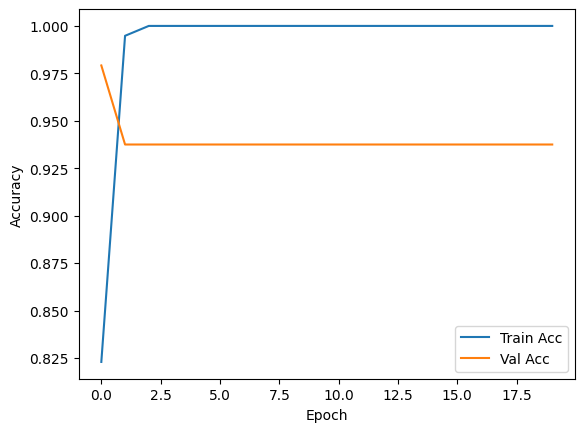

In [ ]:
print(confusion_matrix(y_test, y_pred))
# Visualize training history
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

**Step 12: Save Model and Scaler Save the trained model in .h5 format and the scaler in .pkl**

In [ ]:
# format for deployment use.
# Save the trained model

import pickle
# 1. Save Model
# Using the .h5 format
model.save('day_night_model.h5')

print("✅ Model successfully saved as: day_night_model.h5")
# 2. Save Scaler
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

✅ Model successfully saved as: day_night_model.h5
